# Task 1: Inner Workings of ResNet-152
EE-5102/CS-6304 - Advanced Topics in Machine Learning - Programming Assignment 0

This notebook implements all subtasks of the CNN section:
1. Baseline setup (pretrained ResNet-152, linear-probe on CIFAR-10)
2. Residual connections ablation (skip-connection removal)
3. Feature hierarchies and representations (t-SNE / UMAP)
4. Transfer learning and generalization (classification head vs. full network) x (pretrained vs. random-init weights) -- 4 ablations, 10 epochs each
5. Optional experiments (t-SNE vs UMAP, confusion analysis, ResNet-152 vs ResNet-18)


## 0. Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy, time, random
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "../data"

# GPU info
print("Using device:", device)
if torch.cuda.is_available():
    print(f"Num GPUs: {torch.cuda.device_count()}")

    current_device = torch.cuda.current_device()
    print(f"Current Device Index: {current_device}")
    print(f"Device Name: {torch.cuda.get_device_name(current_device)}")

    props = torch.cuda.get_device_properties(current_device)
    print(f"Total Memory: {props.total_memory / 1e9:.2f} GB")
    print(f"CUDA Capability: {props.major}.{props.minor}")
else:
    print("PyTorch is currently using the CPU.")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


import os
WEIGHTS_DIR = "../weights/part1_test1/"
os.makedirs(WEIGHTS_DIR, exist_ok=True)

NUM_EPOCHS = 10          # epochs for baseline / residual-connection experiments (Parts 1 & 2)
ABLATION_EPOCHS = 10     # epochs per transfer-learning ablation (Part 4)

# Mixed-precision training (autocast + GradScaler). Only actually mixed-precision on CUDA;
# falls back to full precision automatically on CPU.
USE_AMP = device.type == "cuda"
print(f"Mixed precision (AMP) enabled: {USE_AMP}")

# Global plotting style -- seaborn theme applied to every matplotlib figure in the notebook
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"


Using device: cuda
Num GPUs: 1
Current Device Index: 0
Device Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Total Memory: 6.09 GB
CUDA Capability: 8.6
Mixed precision (AMP) enabled: True


### Data: CIFAR-10
ResNet-152 expects 224×224 RGB images normalized with ImageNet statistics. We resize CIFAR-10
(32×32) accordingly and apply standard augmentation for training.

In [2]:
# # !! only run on Colab after uploading the dataset to drive, otherwise no need locally (if dataset is downloaded already)
# import os
# import tarfile
# from google.colab import drive

# # mount Google Drive
# drive.mount('/content/drive')

# # extract the CIFAR-10 archive to local Colab memory (../data)
# os.makedirs(DATA_DIR, exist_ok=True)

# # path to dataset file on Google Drive
# tar_path = "/content/drive/MyDrive/CIFAR/cifar-10-python.tar.gz"

# # extract archive if not already extracted
# if not os.path.exists(os.path.join(DATA_DIR, "cifar-10-batches-py")):
#     print("Extracting CIFAR-10 dataset from Google Drive...")
#     with tarfile.open(tar_path, "r:gz") as tar:
#         tar.extractall(path=DATA_DIR)
#     print("Extraction complete!")
# else:
#     print("Dataset already extracted.")

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Two views of the CIFAR-10 train split: one with augmentation (for training),
# one without (for validation), plus the official CIFAR-10 test split (held out,
# only used for the final test accuracy / F1 reported per ablation).
train_set      = datasets.CIFAR10(root=DATA_DIR, train=True,  download=False, transform=train_tfms)
train_set_eval = datasets.CIFAR10(root=DATA_DIR, train=True,  download=False, transform=eval_tfms)
test_set       = datasets.CIFAR10(root=DATA_DIR, train=False, download=False, transform=eval_tfms)

# Use subsets for speed during development; increase for final results.
TRAIN_SUBSET = 4000
VAL_SUBSET   = 1000
TEST_SUBSET  = 2000

train_indices = np.random.choice(len(train_set), TRAIN_SUBSET, replace=False)
val_indices   = np.random.choice(len(test_set), VAL_SUBSET, replace=False)
test_indices  = np.random.choice(len(test_set), TEST_SUBSET, replace=False)

train_subset = torch.utils.data.Subset(train_set, train_indices)
val_subset   = torch.utils.data.Subset(test_set, val_indices)
test_subset  = torch.utils.data.Subset(test_set, test_indices)

BATCH_SIZE = 16
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_subset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

classes = train_set.classes
print(classes)
print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test (held-out): {len(test_subset)}")


/mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA0/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 4000 | Val: 1000 | Test (held-out): 2000


## 1. Baseline Setup

Load a pretrained ResNet-152, replace the final FC layer to output 10 classes (CIFAR-10),
freeze the backbone, and train only the classification head.

In [4]:
import os
import torch
import torch.nn as nn
from torchvision import models

# Set the directory where PyTorch hub / torchvision downloads model weights
torch.hub.set_dir(os.path.abspath("../weights"))

def build_resnet152_head_only(num_classes=10, pretrained=True):
    weights = models.ResNet152_Weights.IMAGENET1K_V2 if pretrained else None
    model = models.resnet152(weights=weights)

    # Freeze all backbone parameters
    for p in model.parameters():
        p.requires_grad = False

    # Replace the final classification layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model.to(device)

baseline_model = build_resnet152_head_only(num_classes=10, pretrained=True)

trainable = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in baseline_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.4f}%)")

Trainable params: 20,490 / 58,164,298 (0.0352%)


In [5]:
from sklearn.metrics import accuracy_score, f1_score

def train_one_epoch(model, loader, optimizer, criterion, scaler, epoch, total_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    desc = f"Epoch {epoch}/{total_epochs} [Train]"
    pbar = tqdm(loader, desc=desc, leave=False)

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, enabled=USE_AMP):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

        # Update live metrics (accuracy as a percentage)
        pbar.set_postfix(
            loss=f"{running_loss / total:.4f}", acc=f"{100 * correct / total:.2f}%"
        )

    return running_loss / total, 100 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, epoch, total_epochs):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    desc = f"Epoch {epoch}/{total_epochs} [Val]"
    pbar = tqdm(loader, desc=desc, leave=False)

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(device_type=device.type, enabled=USE_AMP):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

        pbar.set_postfix(
            loss=f"{running_loss / total:.4f}", acc=f"{100 * correct / total:.2f}%"
        )

    return running_loss / total, 100 * correct / total


@torch.no_grad()
def evaluate_test(model, loader):
    """Final held-out test-set evaluation.
    Returns (test_accuracy_pct, test_macro_f1_pct)."""
    model.eval()
    all_preds, all_labels = [], []

    for imgs, labels in tqdm(loader, desc="[Test]", leave=False):
        imgs = imgs.to(device)
        with autocast(device_type=device.type, enabled=USE_AMP):
            outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    test_acc = 100 * accuracy_score(all_labels, all_preds)
    test_f1 = 100 * f1_score(all_labels, all_preds, average="macro")
    return test_acc, test_f1


def run_training(model, train_loader, val_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    # GradScaler enables loss scaling for mixed-precision training; it is a no-op
    # (and safe) when USE_AMP is False.
    scaler = GradScaler(device.type, enabled=USE_AMP)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, epoch, epochs
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, epoch, epochs
        )

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - t0

        print(
            f"Epoch {epoch}/{epochs} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.2f}% | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}% | "
            f"{elapsed:.1f}s"
        )

    return history


In [ ]:
baseline_history = run_training(baseline_model, train_loader, val_loader, epochs=NUM_EPOCHS, lr=1e-3)
torch.save(baseline_model.state_dict(), os.path.join(WEIGHTS_DIR, "baseline_resnet152_head.pt"))


Epoch 1/10 | train_loss=1.2029 train_acc=65.12% | val_loss=0.7849 val_acc=79.00% | 29.0s


Epoch 2/10 | train_loss=0.7336 train_acc=77.10% | val_loss=0.6772 val_acc=79.20% | 28.4s


Epoch 3/10 | train_loss=0.6441 train_acc=78.95% | val_loss=0.6231 val_acc=79.90% | 29.8s


Epoch 4/10 | train_loss=0.5780 train_acc=81.10% | val_loss=0.6150 val_acc=80.40% | 28.6s


Epoch 5/10 | train_loss=0.5403 train_acc=82.22% | val_loss=0.5774 val_acc=81.20% | 29.2s


Epoch 6/10 | train_loss=0.5107 train_acc=83.08% | val_loss=0.5883 val_acc=81.00% | 30.2s


Epoch 7/10 | train_loss=0.4795 train_acc=84.00% | val_loss=0.5545 val_acc=81.50% | 28.2s


Epoch 8/10 | train_loss=0.4684 train_acc=84.78% | val_loss=0.5798 val_acc=82.10% | 30.5s


Epoch 9/10 | train_loss=0.4359 train_acc=85.35% | val_loss=0.5678 val_acc=81.10% | 35.4s


Epoch 10/10 | train_loss=0.4278 train_acc=86.08% | val_loss=0.5577 val_acc=82.60% | 36.0s


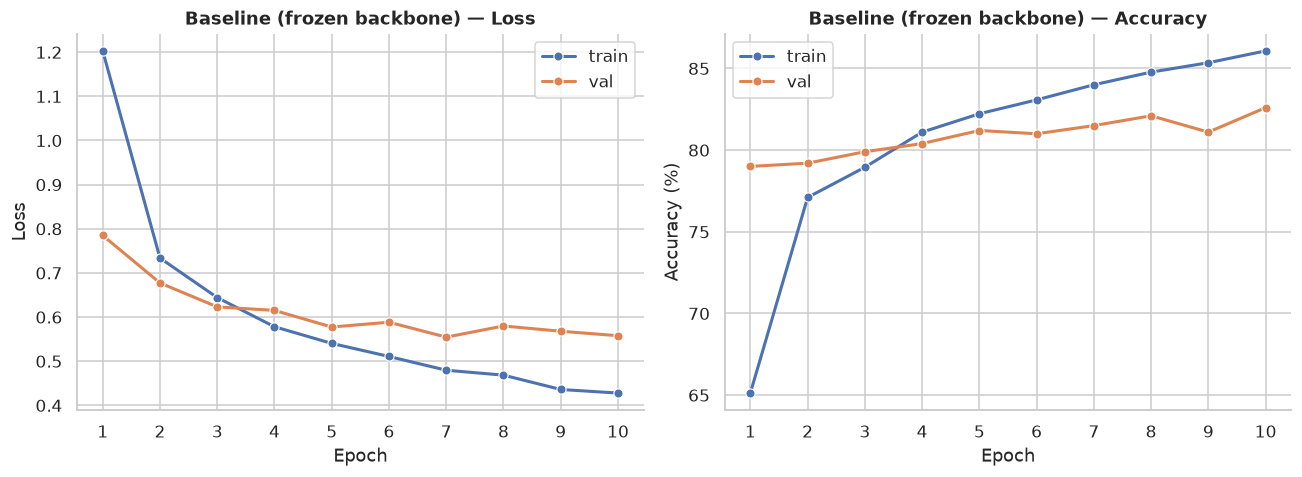

In [ ]:
from matplotlib.ticker import MaxNLocator

def plot_history(history, title="Training curves"):
    epochs = list(range(1, len(history["train_loss"]) + 1))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # --- Loss plot ---
    sns.lineplot(x=epochs, y=history["train_loss"], marker="o", linewidth=2, label="train", ax=axes[0])
    sns.lineplot(x=epochs, y=history["val_loss"], marker="o", linewidth=2, label="val", ax=axes[0])
    axes[0].set_title(f"{title} \u2014 Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].legend(frameon=True)

    # --- Accuracy plot (percentage) ---
    sns.lineplot(x=epochs, y=history["train_acc"], marker="o", linewidth=2, label="train", ax=axes[1])
    sns.lineplot(x=epochs, y=history["val_acc"], marker="o", linewidth=2, label="val", ax=axes[1])
    axes[1].set_title(f"{title} \u2014 Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].legend(frameon=True)

    sns.despine()
    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline (frozen backbone)")


## 2. Residual Connections in Practice

We modify a few `Bottleneck` blocks so that the skip connection is disabled (identity path
replaced with zeros), then re-train just the head (matching the baseline protocol) and compare.

In [ ]:
from torchvision.models.resnet import Bottleneck

class NoSkipBottleneck(Bottleneck):
    """Bottleneck block with the residual (skip) addition removed."""
    def forward(self, x):
        identity = x

        out = self.conv1(x); out = self.bn1(out); out = self.relu(out)
        out = self.conv2(out); out = self.bn2(out); out = self.relu(out)
        out = self.conv3(out); out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        # out = out + identity   # <-- skip connection disabled
        out = self.relu(out)
        return out


def disable_skip_connections(model, layer_names=("layer1",), fraction=0.5):
    """Convert a fraction of Bottleneck blocks in the given layers to NoSkipBottleneck."""
    for layer_name in layer_names:
        layer = getattr(model, layer_name)
        n_blocks = len(layer)
        n_to_modify = max(1, int(n_blocks * fraction))
        for i in range(n_to_modify):
            block = layer[i]
            block.__class__ = NoSkipBottleneck  # swap forward() via class reassignment
    return model


In [ ]:
noskip_model = build_resnet152_head_only(num_classes=10, pretrained=True)
noskip_model = disable_skip_connections(noskip_model, layer_names=("layer1", "layer2"), fraction=0.5)

noskip_history = run_training(noskip_model, train_loader, val_loader, epochs=NUM_EPOCHS, lr=1e-3)


Epoch 1/10 | train_loss=2.2856 train_acc=14.60% | val_loss=2.2089 val_acc=18.40% | 30.7s


Epoch 2/10 | train_loss=2.2172 train_acc=17.68% | val_loss=2.1951 val_acc=18.20% | 29.7s


Epoch 3/10 | train_loss=2.1887 train_acc=19.65% | val_loss=2.1654 val_acc=20.30% | 28.2s


Epoch 4/10 | train_loss=2.1871 train_acc=18.68% | val_loss=2.1584 val_acc=19.80% | 28.9s


Epoch 5/10 | train_loss=2.1768 train_acc=19.88% | val_loss=2.1380 val_acc=21.40% | 29.3s


Epoch 6/10 | train_loss=2.1494 train_acc=19.73% | val_loss=2.1308 val_acc=21.30% | 29.4s


Epoch 7/10 | train_loss=2.1493 train_acc=20.73% | val_loss=2.1775 val_acc=20.00% | 28.2s


Epoch 8/10 | train_loss=2.1439 train_acc=21.55% | val_loss=2.1671 val_acc=21.50% | 28.1s


Epoch 9/10 | train_loss=2.1412 train_acc=21.77% | val_loss=2.1418 val_acc=22.00% | 28.3s


Epoch 10/10 | train_loss=2.1268 train_acc=21.60% | val_loss=2.1239 val_acc=22.60% | 28.1s


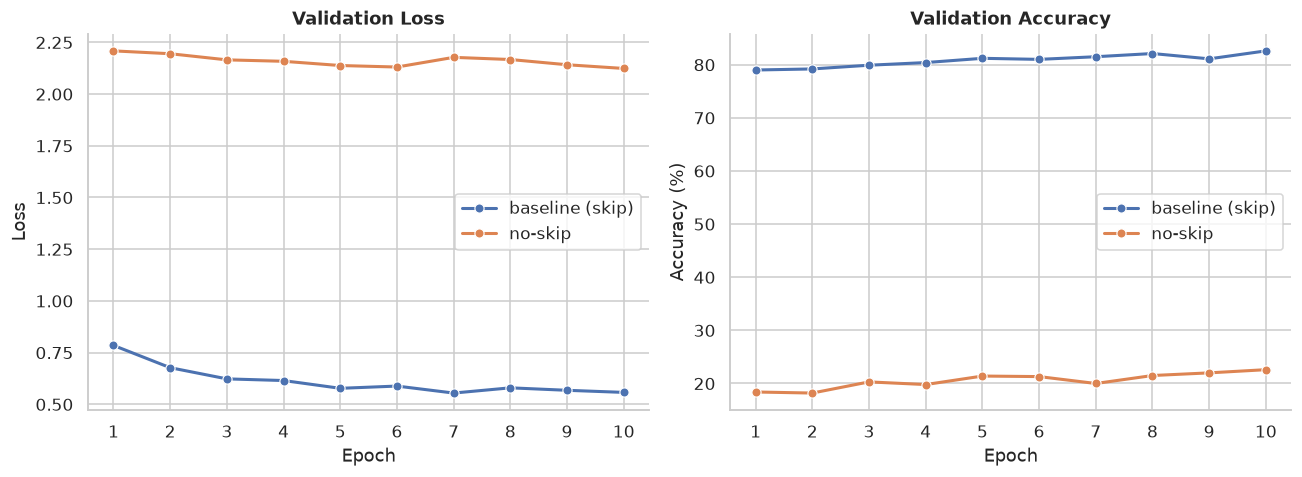

In [ ]:
epochs = list(range(1, len(baseline_history["val_loss"]) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.lineplot(x=epochs, y=baseline_history["val_loss"], marker="o", linewidth=2, label="baseline (skip)", ax=axes[0])
sns.lineplot(x=epochs, y=noskip_history["val_loss"], marker="o", linewidth=2, label="no-skip", ax=axes[0])
axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].legend(frameon=True)

sns.lineplot(x=epochs, y=baseline_history["val_acc"], marker="o", linewidth=2, label="baseline (skip)", ax=axes[1])
sns.lineplot(x=epochs, y=noskip_history["val_acc"], marker="o", linewidth=2, label="no-skip", ax=axes[1])
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].legend(frameon=True)

sns.despine()
plt.tight_layout()
plt.show()


## 3. Feature Hierarchies and Representations

We register forward hooks on an early, middle, and late layer of ResNet-152, collect pooled
features on a batch of CIFAR-10 test images, then visualize with t-SNE / UMAP.

In [ ]:
features = {}

def get_hook(name):
    def hook(module, inp, out):
        features[name] = out.detach()
    return hook

feat_model = build_resnet152_head_only(num_classes=10, pretrained=True)
feat_model.eval()

hook_handles = [
    feat_model.layer1.register_forward_hook(get_hook("early")),   # early
    feat_model.layer3.register_forward_hook(get_hook("middle")),  # middle
    feat_model.layer4.register_forward_hook(get_hook("late")),    # late
]


In [ ]:
@torch.no_grad()
def collect_features(model, loader, n_batches=8):
    all_feats = {"early": [], "middle": [], "late": []}
    all_labels = []
    pool = nn.AdaptiveAvgPool2d(1)

    for i, (imgs, labels) in enumerate(loader):
        if i >= n_batches:
            break
        imgs = imgs.to(device)
        _ = model(imgs)
        for k in all_feats:
            pooled = pool(features[k]).flatten(1).cpu().numpy()  # global-avg-pool -> (B, C)
            all_feats[k].append(pooled)
        all_labels.append(labels.numpy())

    for k in all_feats:
        all_feats[k] = np.concatenate(all_feats[k], axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_feats, all_labels

layer_feats, layer_labels = collect_features(feat_model, val_loader, n_batches=20)
for k, v in layer_feats.items():
    print(k, v.shape)

for h in hook_handles:
    h.remove()


early (320, 256)
middle (320, 1024)
late (320, 2048)


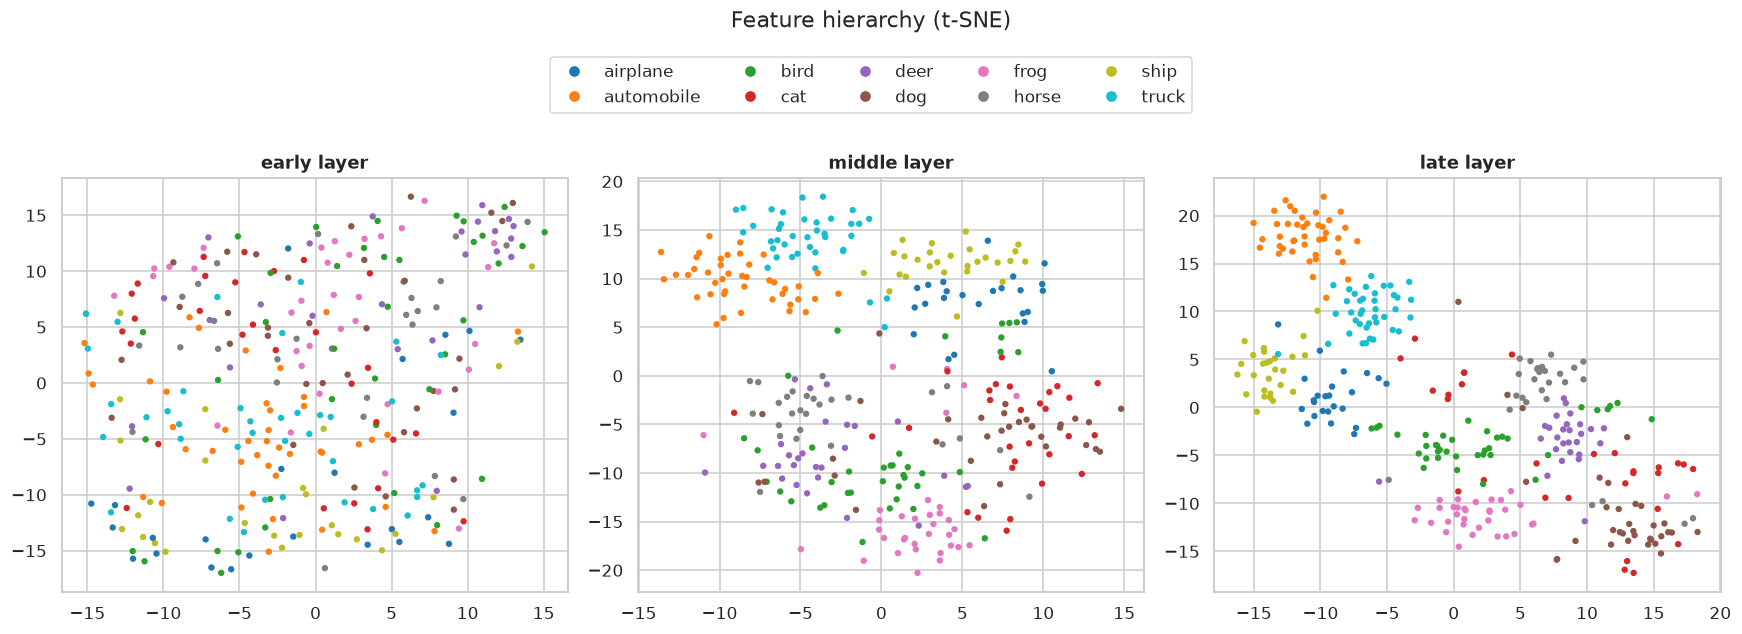

In [ ]:
from sklearn.manifold import TSNE

def plot_tsne(feat_dict, labels, class_names, title="Feature hierarchy (t-SNE)"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (name, feats) in zip(axes, feat_dict.items()):
        emb = TSNE(n_components=2, init="pca", random_state=SEED, perplexity=30).fit_transform(feats)
        scatter = ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="tab10", s=10)
        ax.set_title(f"{name} layer")
    handles, _ = scatter.legend_elements()
    fig.legend(handles, class_names, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.08))
    fig.suptitle(title, y=1.15)
    plt.tight_layout(); plt.show()

plot_tsne(layer_feats, layer_labels, classes)


## 4. Transfer Learning and Generalization

We cross **which part of the network is trained** (classification head only vs. the full
network) with **the weight initialization** (ImageNet-pretrained vs. randomly initialized),
giving four ablations:

1. Classification head only, pretrained weights
2. Classification head only, random-init weights
3. Full network, pretrained weights
4. Full network, random-init weights

Each ablation trains for `ABLATION_EPOCHS` (10) epochs on the CIFAR-10 train/val split, and is
then scored once on a held-out test split to report **final test accuracy** and **final test
macro-F1**, both as percentages.


In [6]:
def build_resnet152_full(num_classes=10, pretrained=True, finetune="full"):
    """finetune: 'full' (train all layers), 'head' (train fc only),
    or 'last_block' (train layer4 + fc only, used only in the optional Part 5 section)."""
    weights = models.ResNet152_Weights.IMAGENET1K_V2 if pretrained else None
    model = models.resnet152(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    if finetune == "head":
        for name, p in model.named_parameters():
            p.requires_grad = name.startswith("fc")
    elif finetune == "last_block":
        for name, p in model.named_parameters():
            p.requires_grad = name.startswith("layer4") or name.startswith("fc")
    elif finetune == "full":
        for p in model.parameters():
            p.requires_grad = True
    else:
        raise ValueError(finetune)

    return model.to(device)


In [7]:
import gc
import os
import torch
from tqdm import tqdm

configs = [
    # ("head_pretrained",   dict(pretrained=True,  finetune="head")),
    # ("head_random_init",  dict(pretrained=False, finetune="head")),
    ("last_block_pretrained",   dict(pretrained=True,  finetune="last_block")),
    ("last_block_random_init",  dict(pretrained=False, finetune="last_block")),
    ("full_pretrained",   dict(pretrained=True,  finetune="full")),
    ("full_random_init",  dict(pretrained=False, finetune="full")),
]

results = {}       # per-epoch train/val curves for each ablation
test_results = {}  # final held-out test accuracy / macro-F1 (%) for each ablation
torch.cuda.empty_cache()

for name, cfg in configs:
    print(f"\n=== {name} ===")
    gc.collect()
    torch.cuda.empty_cache()

    model = build_resnet152_full(num_classes=10, **cfg)
    lr = 1e-3
    hist = run_training(model, train_loader, val_loader, epochs=ABLATION_EPOCHS, lr=lr)
    results[name] = hist

    test_acc, test_f1 = evaluate_test(model, test_loader)
    test_results[name] = {"test_acc": test_acc, "test_f1": test_f1}
    print(f"  >> Final test accuracy: {test_acc:.2f}% | Final test macro-F1: {test_f1:.2f}%")

    torch.save(model.state_dict(), os.path.join(WEIGHTS_DIR, f"{name}.pt"))

    del model
    gc.collect()
    torch.cuda.empty_cache()



=== last_block_pretrained ===


Epoch 1/10 | train_loss=0.7958 train_acc=74.00% | val_loss=0.4413 val_acc=84.50% | 38.9s


Epoch 2/10 | train_loss=0.3882 train_acc=86.67% | val_loss=0.3933 val_acc=88.00% | 37.3s


Epoch 3/10 | train_loss=0.2523 train_acc=91.80% | val_loss=0.3790 val_acc=87.40% | 37.5s


Epoch 4/10 | train_loss=0.1736 train_acc=94.25% | val_loss=0.4786 val_acc=85.40% | 37.2s


...

Epoch 7/10 | train_loss=1.8696 train_acc=29.48% | val_loss=1.7190 val_acc=34.30% | 80.7s


Epoch 8/10 | train_loss=1.7442 train_acc=33.62% | val_loss=1.6945 val_acc=35.00% | 80.7s


Epoch 9/10 | train_loss=1.7073 train_acc=35.27% | val_loss=1.5987 val_acc=39.50% | 81.0s


Epoch 10/10 | train_loss=1.6782 train_acc=35.17% | val_loss=1.6165 val_acc=39.60% | 81.0s


  >> Final test accuracy: 40.10% | Final test macro-F1: 38.49%


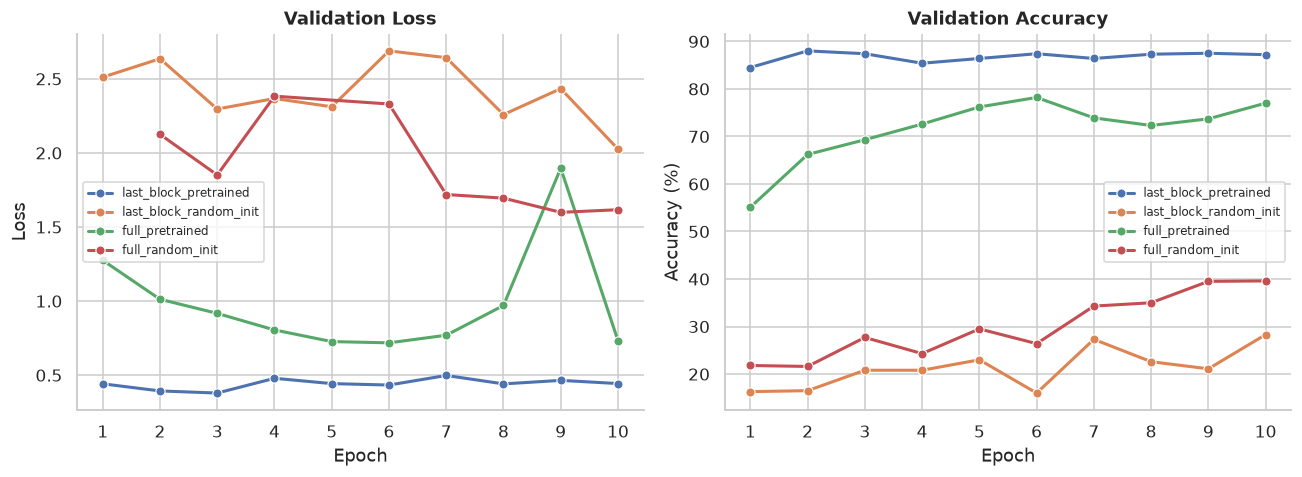

Final test-set metrics per ablation:


,Test Accuracy (%),Test Macro-F1 (%)
last_block_pretrained,86.4,86.41
last_block_random_init,29.7,26.02
full_pretrained,78.8,78.79
full_random_init,40.1,38.49


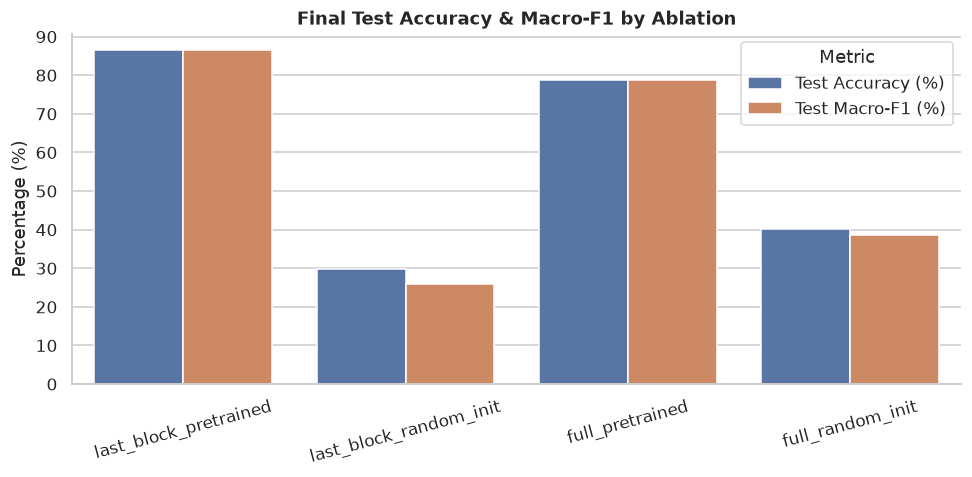

In [8]:
import pandas as pd
from matplotlib.ticker import MaxNLocator

epochs = list(range(1, ABLATION_EPOCHS + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name, hist in results.items():
    sns.lineplot(x=epochs, y=hist["val_loss"], marker="o", linewidth=2, label=name, ax=axes[0])
    sns.lineplot(x=epochs, y=hist["val_acc"], marker="o", linewidth=2, label=name, ax=axes[1])

axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].legend(fontsize=8, frameon=True)

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].legend(fontsize=8, frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

# --- Final test accuracy / macro-F1 summary table (percentages) ---
summary_df = pd.DataFrame(test_results).T
summary_df = summary_df.rename(columns={"test_acc": "Test Accuracy (%)", "test_f1": "Test Macro-F1 (%)"})
summary_df = summary_df.round(2)
print("Final test-set metrics per ablation:")
display(summary_df)


# --- Bar chart of the same summary ---
import matplotlib.ticker as ticker

summary_melt = summary_df.reset_index().rename(columns={"index": "Ablation"}).melt(
    id_vars="Ablation", var_name="Metric", value_name="Value"
)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=summary_melt, x="Ablation", y="Value", hue="Metric", ax=ax)

# Set y-axis increments to 10
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))

ax.set_xlabel("")
ax.set_ylabel("Percentage (%)")
ax.set_title("Final Test Accuracy & Macro-F1 by Ablation")
plt.xticks(rotation=15)
sns.despine()
plt.tight_layout()
plt.show()


## 5. Optional Experiments

### 5a. t-SNE vs. UMAP

/home/ayaan/custom_venvs/cuda_pytorch/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


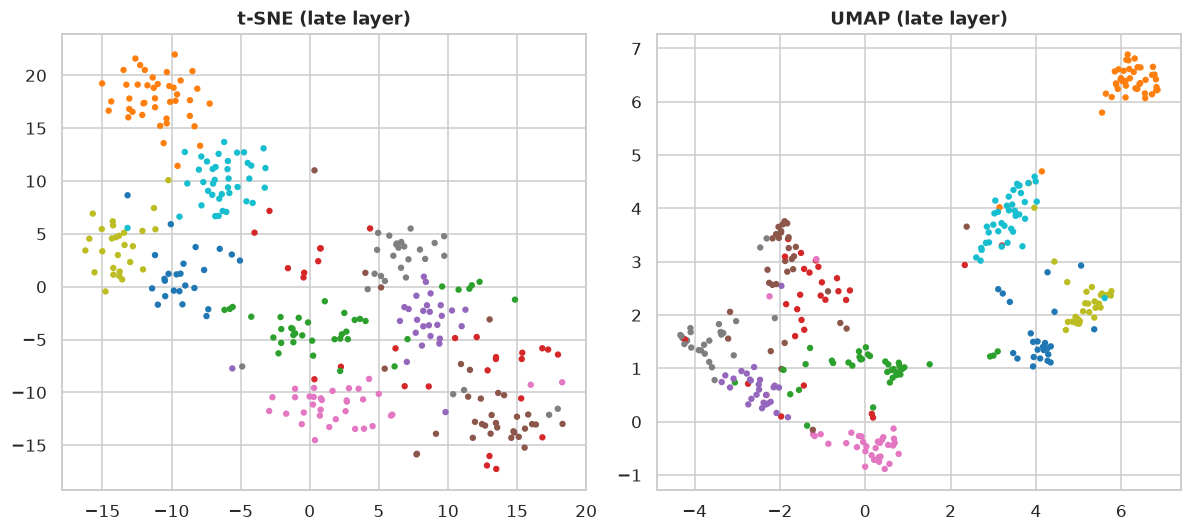

In [ ]:
try:
    import umap
    HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False
    print("umap-learn not installed; run `pip install umap-learn` to enable this section.")

if HAVE_UMAP:
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    late_feats = layer_feats["late"]

    tsne_emb = TSNE(n_components=2, init="pca", random_state=SEED).fit_transform(late_feats)
    axes[0].scatter(tsne_emb[:, 0], tsne_emb[:, 1], c=layer_labels, cmap="tab10", s=10)
    axes[0].set_title("t-SNE (late layer)")

    umap_emb = umap.UMAP(n_components=2, random_state=SEED).fit_transform(late_feats)
    axes[1].scatter(umap_emb[:, 0], umap_emb[:, 1], c=layer_labels, cmap="tab10", s=10)
    axes[1].set_title("UMAP (late layer)")
    plt.tight_layout(); plt.show()



### 5b. Confused-class analysis

Epoch 1/10 | train_loss=1.1065 train_acc=67.55% | val_loss=0.5095 val_acc=83.90% | 32.6s


Epoch 2/10 | train_loss=0.4954 train_acc=84.72% | val_loss=0.4560 val_acc=85.10% | 33.9s


Epoch 3/10 | train_loss=0.3661 train_acc=87.95% | val_loss=0.4194 val_acc=87.50% | 32.9s


Epoch 4/10 | train_loss=0.2656 train_acc=92.05% | val_loss=0.3941 val_acc=87.20% | 32.4s


Epoch 5/10 | train_loss=0.1988 train_acc=93.15% | val_loss=0.4319 val_acc=85.50% | 34.0s


Epoch 6/10 | train_loss=0.1664 train_acc=94.92% | val_loss=0.4523 val_acc=86.70% | 32.4s


Epoch 7/10 | train_loss=0.1363 train_acc=95.75% | val_loss=0.4560 val_acc=86.80% | 33.2s


Epoch 8/10 | train_loss=0.1072 train_acc=96.83% | val_loss=0.4467 val_acc=87.10% | 32.3s


Epoch 9/10 | train_loss=0.0930 train_acc=97.35% | val_loss=0.4230 val_acc=87.20% | 33.3s


Epoch 10/10 | train_loss=0.0829 train_acc=97.12% | val_loss=0.4756 val_acc=86.90% | 32.2s


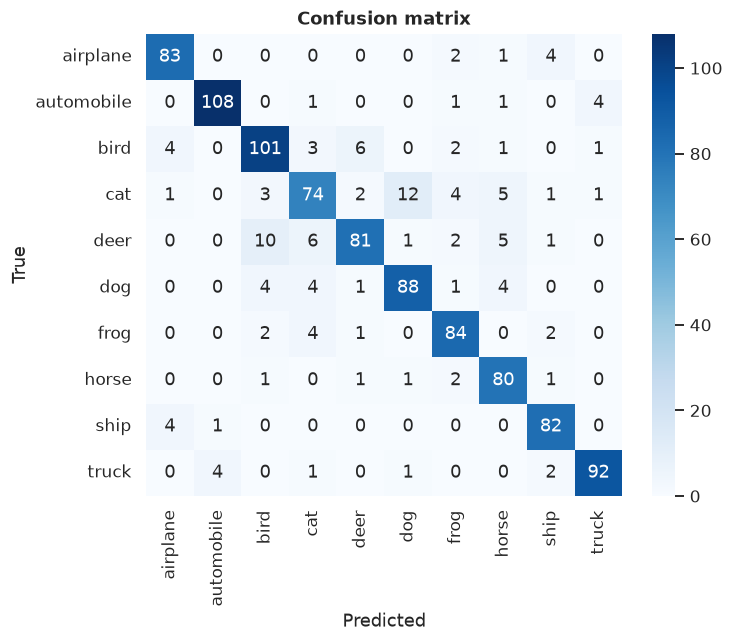

In [ ]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)

from sklearn.metrics import confusion_matrix
import seaborn as sns

best_model = build_resnet152_full(num_classes=10, pretrained=True, finetune="last_block")
_ = run_training(best_model, train_loader, val_loader, epochs=NUM_EPOCHS, lr=1e-4)

preds, labels_arr = get_predictions(best_model, val_loader)
cm = confusion_matrix(labels_arr, preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix")
plt.tight_layout(); plt.show()
torch.save(best_model.state_dict(), os.path.join(WEIGHTS_DIR, "best_model_last_block.pt"))



### 5c. ResNet-152 vs. ResNet-18 feature quality

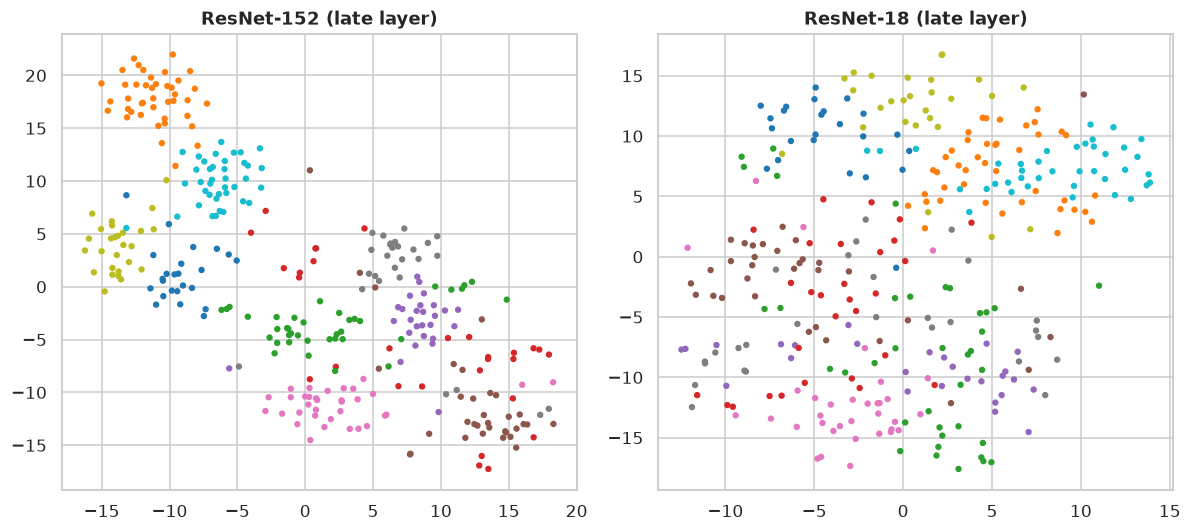

In [ ]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device)
resnet18.eval()

r18_features = {}
h = resnet18.layer4.register_forward_hook(lambda m, i, o: r18_features.__setitem__("late", o.detach()))

@torch.no_grad()
def collect_single_layer(model, hook_store, key, loader, n_batches=8):
    feats, labs = [], []
    pool = nn.AdaptiveAvgPool2d(1)
    for i, (imgs, labels) in enumerate(loader):
        if i >= n_batches:
            break
        imgs = imgs.to(device)
        _ = model(imgs)
        pooled = pool(hook_store[key]).flatten(1).cpu().numpy()
        feats.append(pooled); labs.append(labels.numpy())
    return np.concatenate(feats), np.concatenate(labs)

r18_feats, r18_labels = collect_single_layer(resnet18, r18_features, "late", val_loader, n_batches=20)
h.remove()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
emb152 = TSNE(n_components=2, init="pca", random_state=SEED).fit_transform(layer_feats["late"])
axes[0].scatter(emb152[:, 0], emb152[:, 1], c=layer_labels, cmap="tab10", s=10)
axes[0].set_title("ResNet-152 (late layer)")

emb18 = TSNE(n_components=2, init="pca", random_state=SEED).fit_transform(r18_feats)
axes[1].scatter(emb18[:, 0], emb18[:, 1], c=r18_labels, cmap="tab10", s=10)
axes[1].set_title("ResNet-18 (late layer)")
plt.tight_layout(); plt.show()


In [ ]:
# /weights/checkpoints
# 1. Zip the folder (Replace 'my_folder' with your actual folder name)
!zip -r weights_part1.zip /weights/

# 2. Download the zip file to your local computer
from google.colab import files
files.download('weights_part1.zip')


zsh:1: command not found: zip


ModuleNotFoundError: No module named 'google.colab'